- # ```Refresh, Updates, Deletes, and Consistency```

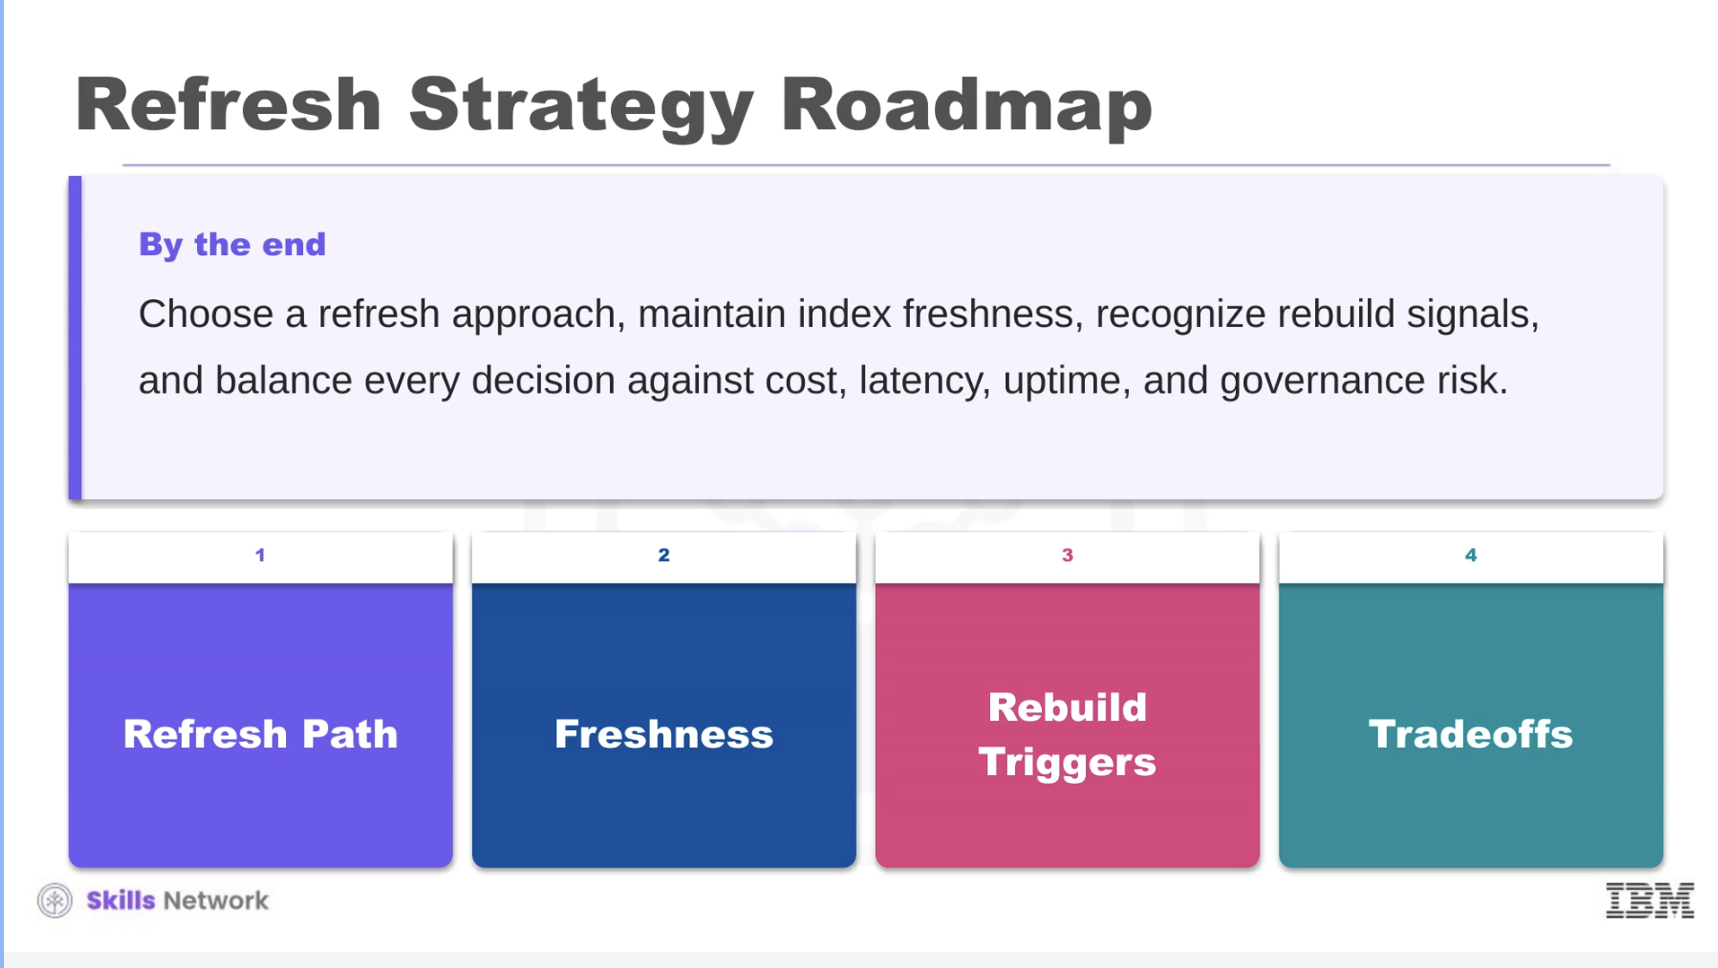
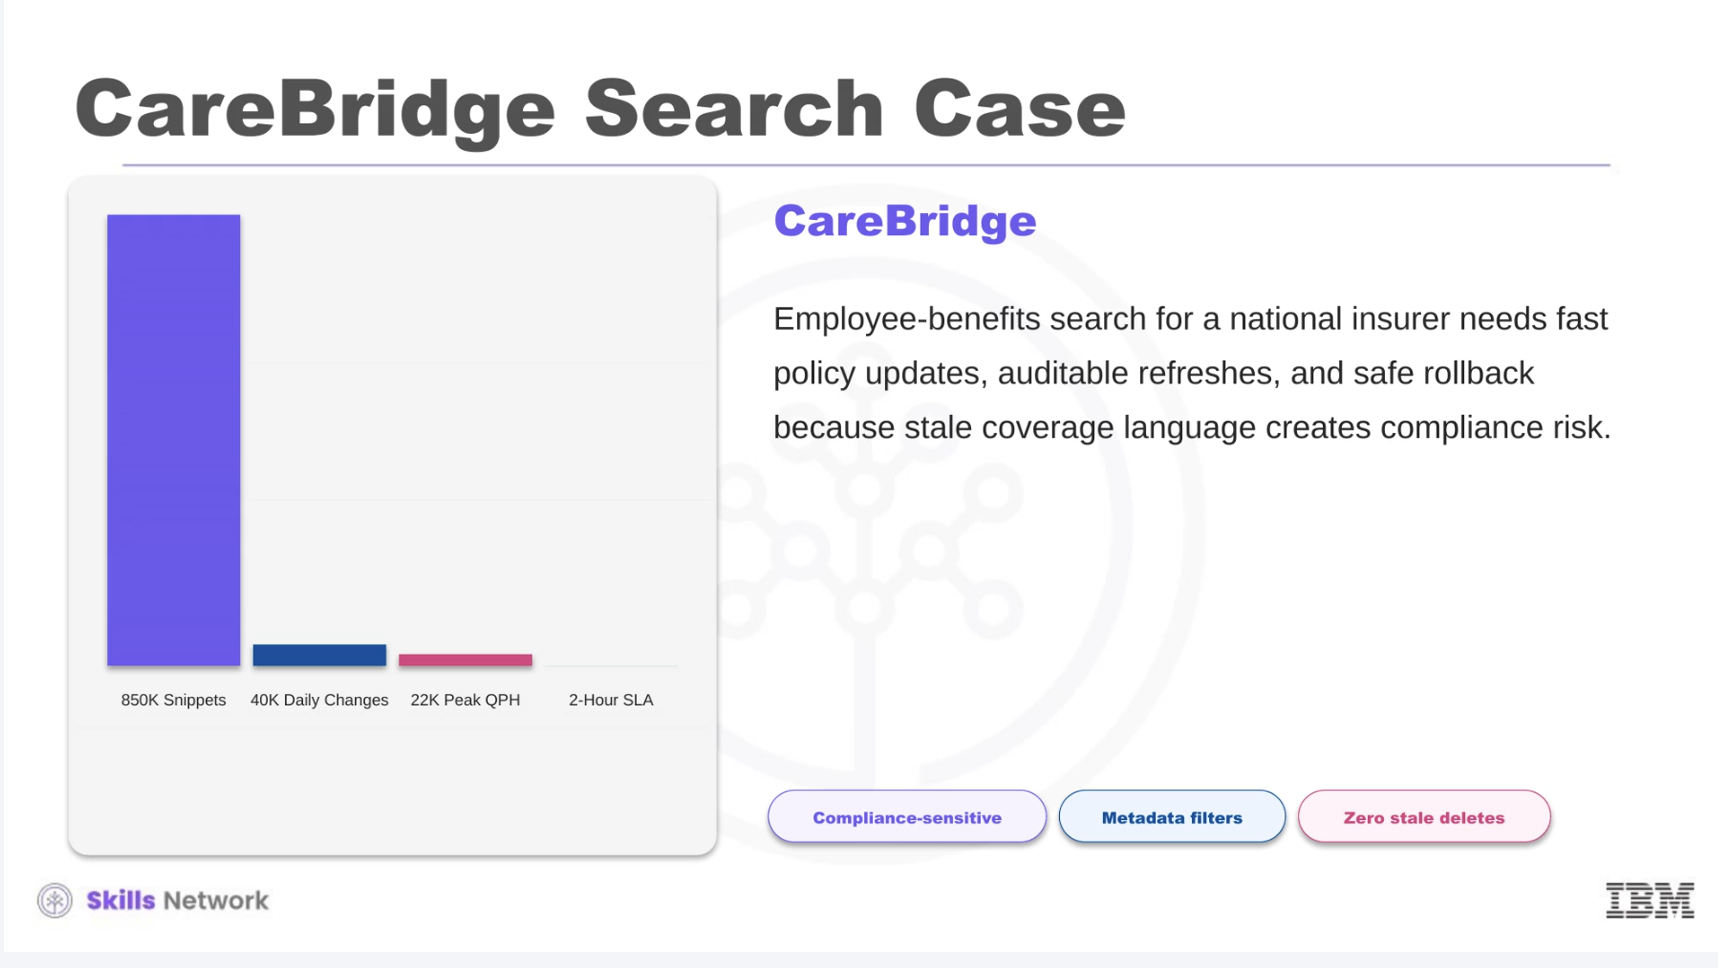
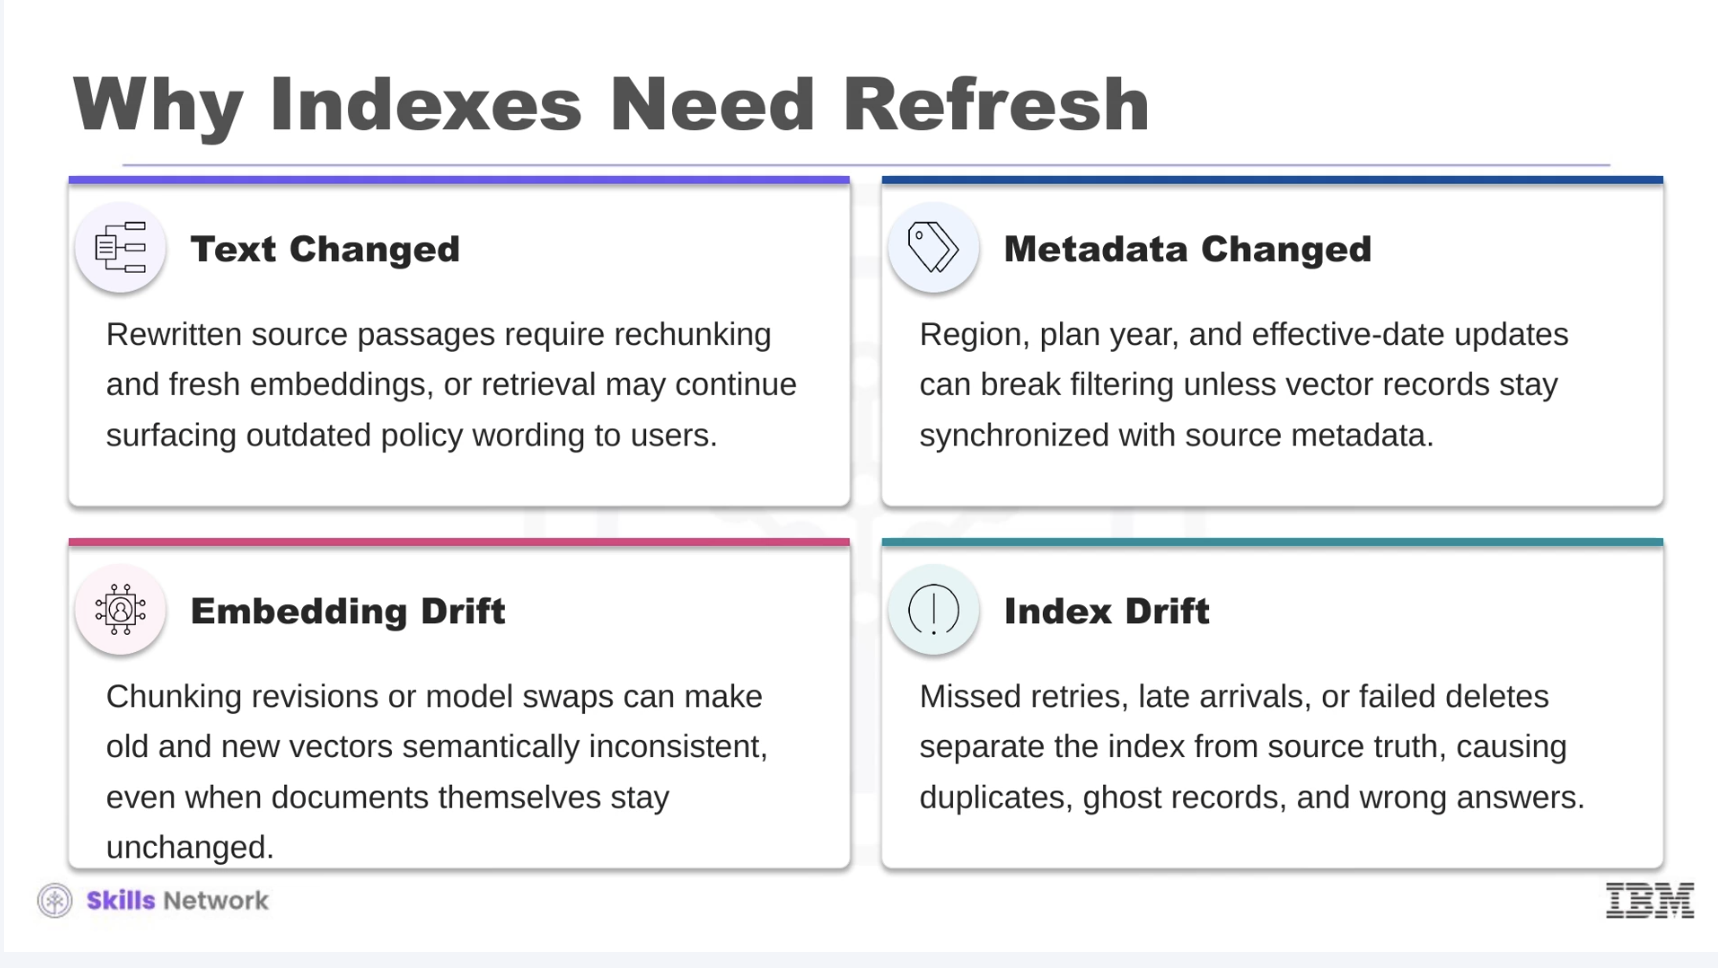
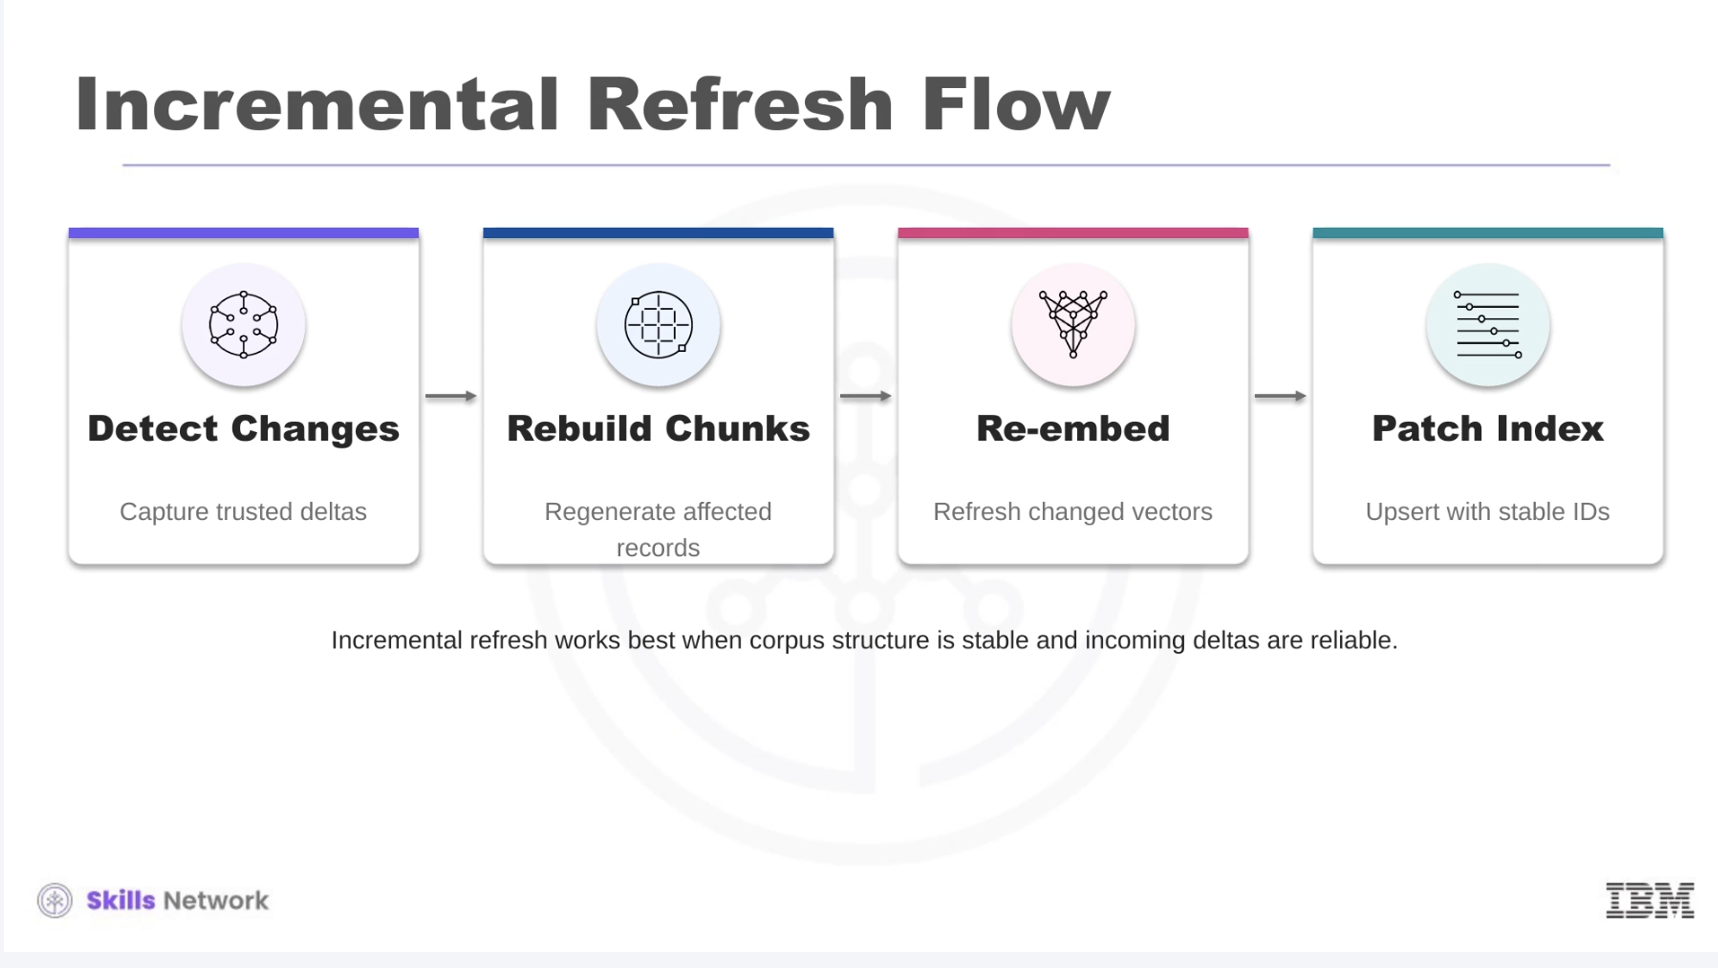
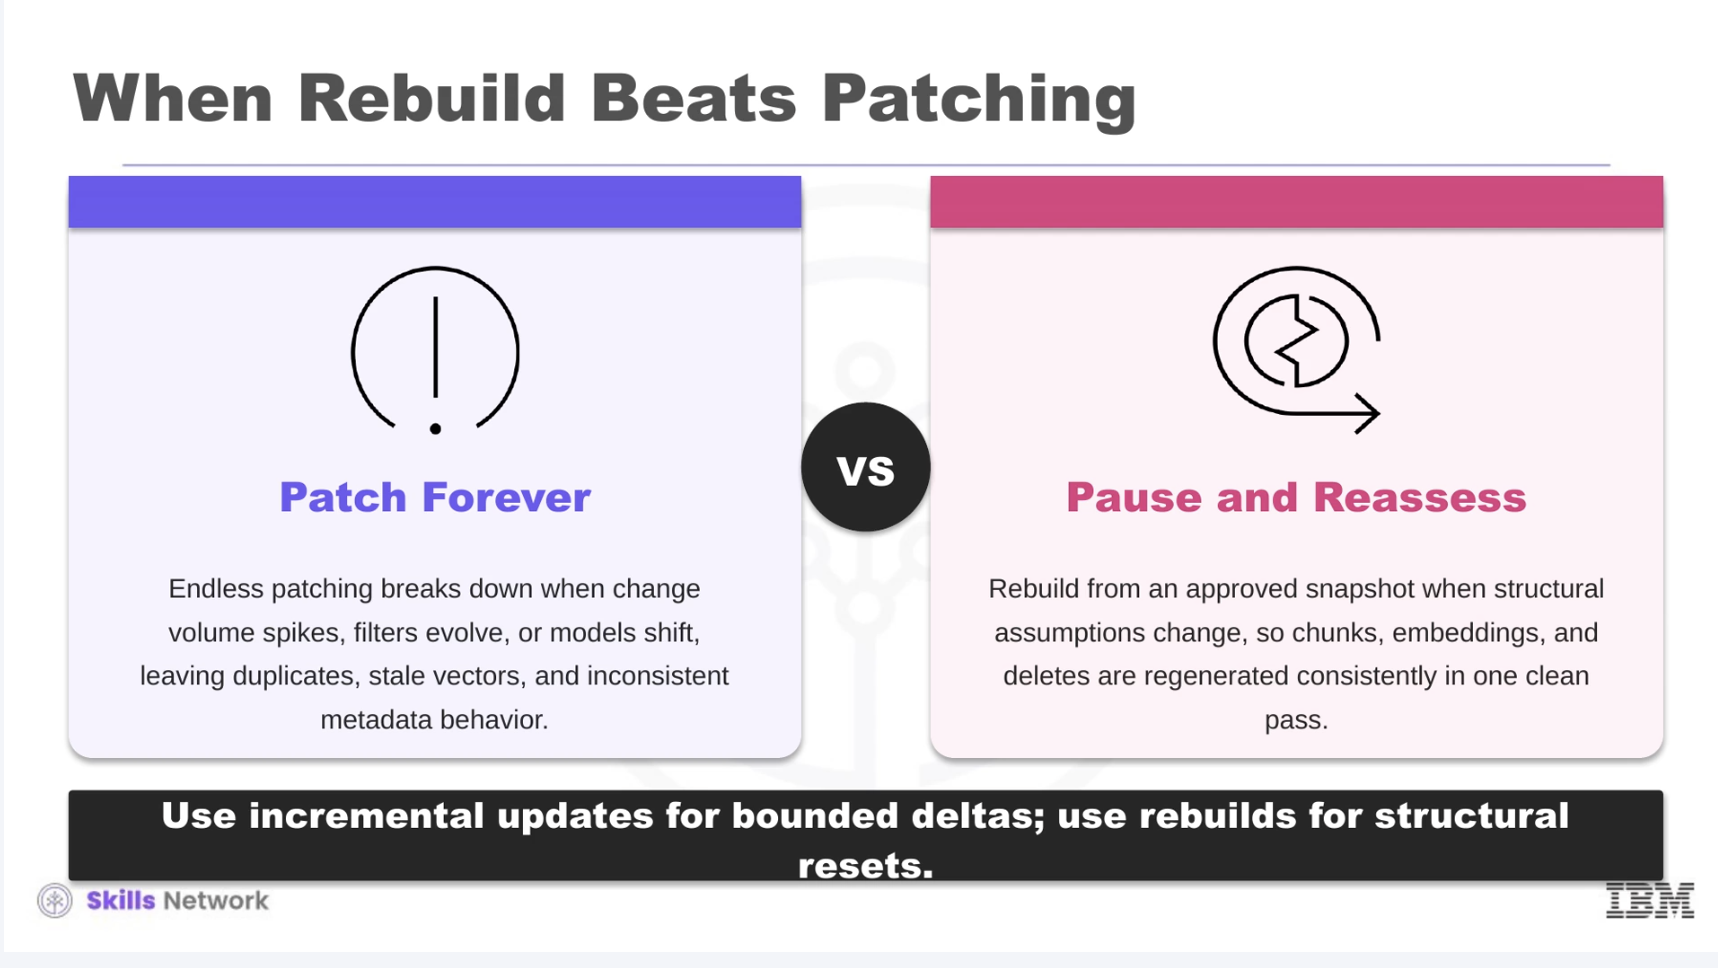
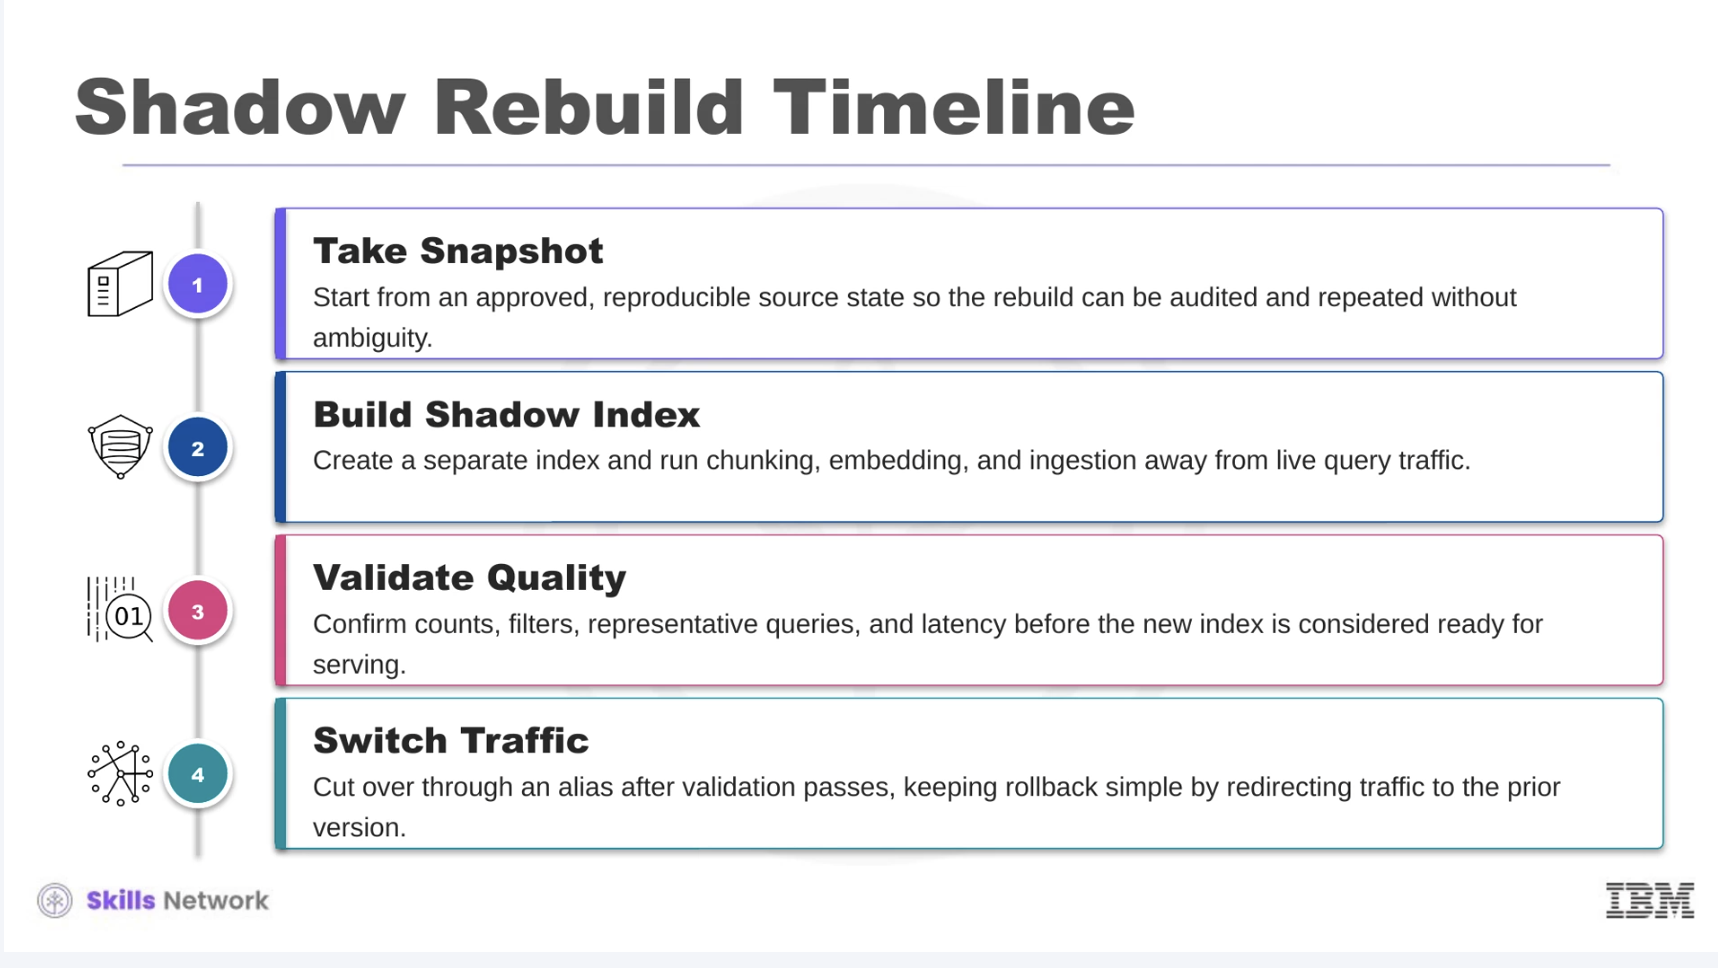
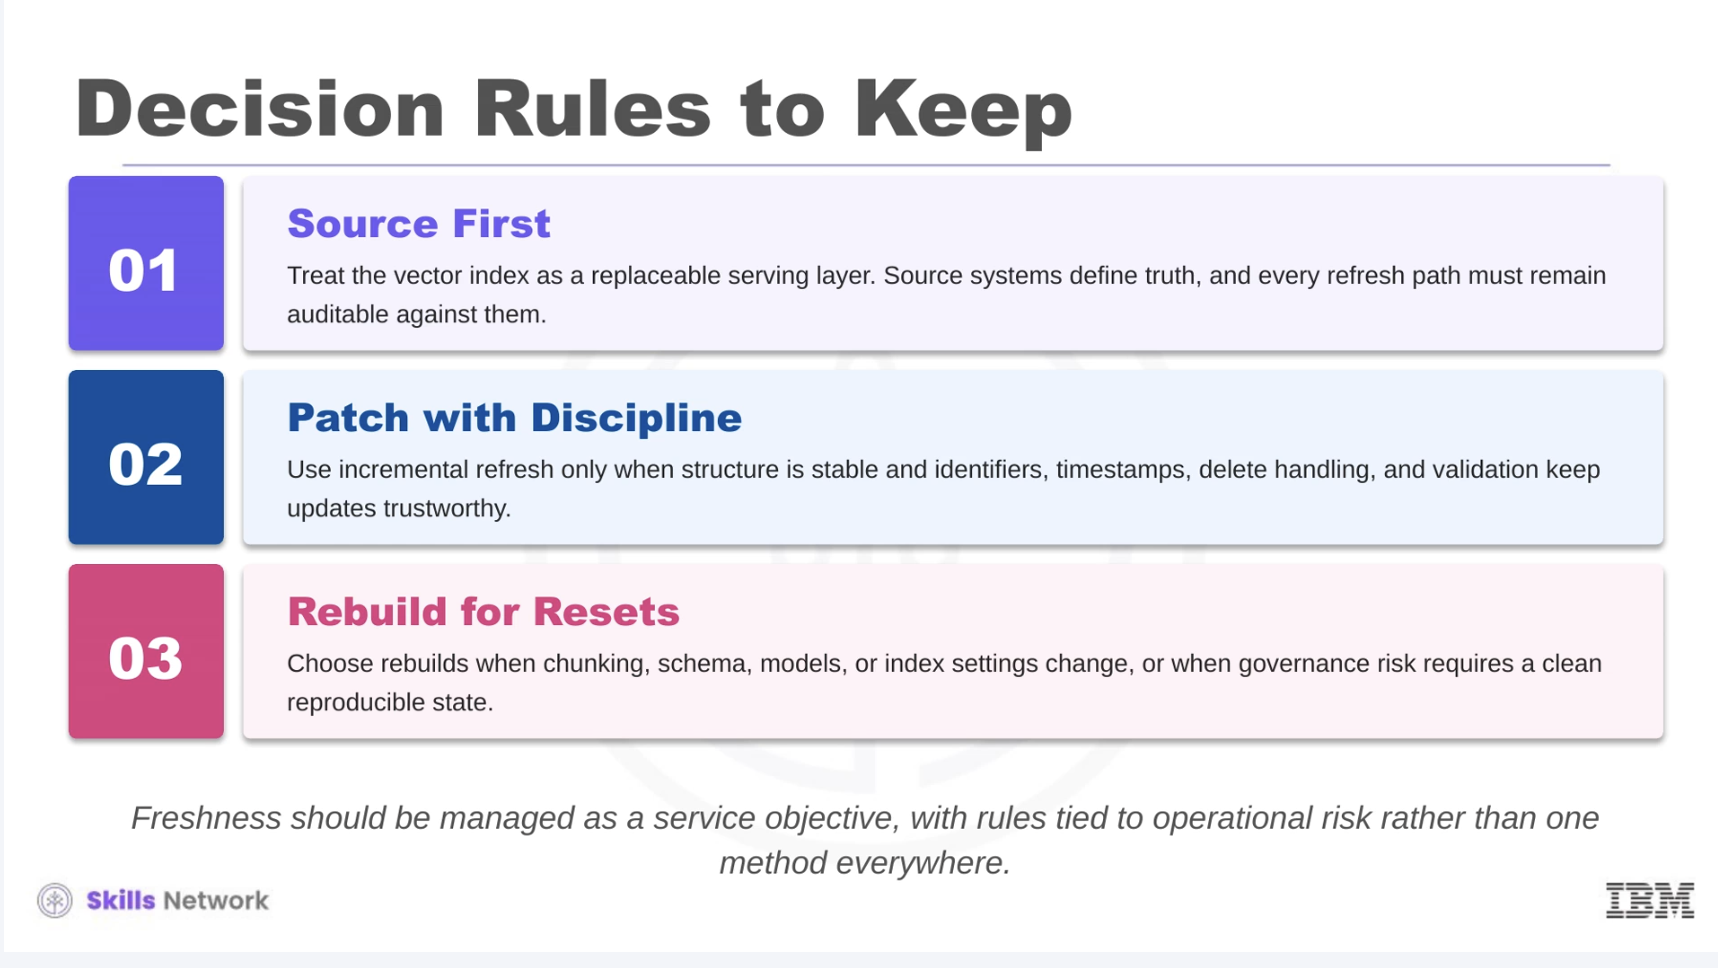



# Keeping the Vector Index in Sync with the Source

> 💡 **Core lesson:** The vector DB is a *derived copy* of the source. Keeping it synchronized with reality is not just a relevance problem — in security-focused RAG, staleness can become an **authorization** problem.

---

## 1. The Core Problem: Your Vector DB Is a Derived Copy

This is the single most important idea in this chapter.

My source system might look like:

```
CMS / Database / Document Store
              ↓
        RAG Pipeline
              ↓
       Chunking + Embedding
              ↓
         Vector Database
```

> 📌 The vector DB is **not** the source of truth. It's a **derived representation** of the source.

So imagine:

```
Source:
"Employees may access this document."

Vector DB:
embedding("Employees may access this document.")
```

Then someone changes the source to:

```
"Managers may access this document."
```

My vector DB may still contain:

```
embedding("Employees may access this document.")
```

| | State |
|---|---|
| Source | ✅ Correct |
| Vector DB | ❌ **Stale** |

And this is more dangerous than ordinary database staleness because **retrieval may actually return the stale content to the LLM**.

---

## 2. Not All Changes Are the Same

This is the main lesson of Section 1.

When something changes, don't just ask:

> "Did the document change?"

Ask:

> **"Which layer changed?"**

There are four layers.

### Layer 1 — Content

The actual text changed.

```
"Employees may access..."
        ↓
"Managers may access..."
```

This changes the **meaning**. Therefore:

```
new chunks
    ↓
new embeddings
    ↓
upsert
```

### Layer 2 — Metadata

The text didn't change, but metadata did.

```json
{
    "region": "US",
    "security_label": "internal"
}
```

becomes:

```json
{
    "region": "US",
    "security_label": "restricted"
}
```

The embedding may still be perfectly valid. But the **filtering/security information is now wrong**.

So I may only need:

```
update metadata
```

rather than re-embedding.

### Layer 3 — Representation

This is where things get more serious.

Suppose I change:

```
Embedding model A
        ↓
Embedding model B
```

The actual text hasn't changed. But the vectors now live in a **different representation space**.

Similarly:

```
Chunking:
1000-token chunks
        ↓
semantic paragraph chunks
```

The source hasn't changed, but my representation of the source has fundamentally changed.

**That's usually a rebuild/backfill situation.**

### Layer 4 — Index structure

Example:

- HNSW parameters change
- IVF configuration changes
- distance metric changes
- filter schema changes

Again, the underlying source may be identical. But the **retrieval structure** has changed.

That can require a **rebuild or new-index cutover**.

### Summary of the four layers

| Layer | What changed | Source text changed? | Typical action |
|---|---|---|---|
| 1. Content | The actual text | Yes | New chunks → new embeddings → upsert |
| 2. Metadata | Labels / filters / security info | No | Update metadata only |
| 3. Representation | Embedding model / chunking | No | Rebuild / backfill |
| 4. Index structure | HNSW / IVF / metric / filter schema | No | Rebuild / new-index cutover |

---

## 3. Memorize This Change Table

This is probably the most useful table in the chapter:

| Change | Typical action |
|---|---|
| New record | Incremental insert |
| Text changed | Re-embed + upsert |
| Metadata changed | Metadata update/upsert |
| Deleted | Delete / soft delete |
| Embedding model changed | Rebuild/backfill |
| Chunking changed | Rebuild/backfill |
| Index configuration changed | Rebuild/new index |

> 💡 The important distinction is: **Content changes can usually be handled selectively. Representation changes often affect the entire corpus.**

---

## 4. Incremental Refresh

This is what I'll use most of the time.

Suppose my corpus has:

```
10,000,000 documents
```

and today only:

```
2,000 documents changed
```

I obviously don't want to reprocess all 10 million. Instead:

```
Source
  ↓
Detect changed records
  ↓
2,000 records
  ↓
chunk
  ↓
embed
  ↓
upsert
```

That's **incremental refresh**.

### When it's good

When the change is:

- small
- identifiable
- trackable
- compatible with my current representation

Examples:

- New document
- Document text changed
- Metadata changed
- Document deleted
- Access policy changed

---

## 5. ⚠️ But Here's the Trap

The chapter gives a very important warning:

> ⚠️ **Incremental refresh assumes that the current representation contract is still valid.**

Imagine:

```
10M vectors
```

Then I change my embedding model. If I say:

> "I'll just incrementally embed the documents that change."

I now get:

```
9,999,000 vectors → Model A
1,000 vectors     → Model B
```

Now I've **mixed generations**.

That's dangerous because similarity comparisons may no longer behave consistently.

Same thing with chunking:

```
Old:
1000-token chunks

New:
semantic paragraph chunks
```

I shouldn't casually keep mixing them.

---

## 6. Full Rebuild

A full rebuild basically means:

```
Source corpus
     ↓
new pipeline
     ↓
new chunks
     ↓
new embeddings
     ↓
new index
```

rather than modifying the existing index piece by piece.

### Typical reasons

**Embedding model changed**

```
Model A → Model B
```

**Chunking strategy changed**

```
fixed windows → semantic chunks
```

**Major schema change**

```
old metadata structure
        ↓
new metadata structure
```

**Major index configuration change**

Depending on the vector engine, some index changes aren't safely patchable.

---

## 7. ✅ The Production Solution: Hybrid Backfill

This is probably the most important production pattern in this chapter.

I don't necessarily stop my production system. I do:

```
                    ┌───────────────┐
                    │ Current Index │
                    └───────┬───────┘
                            ↑
                       normal traffic

Source
  │
  ├── incremental updates ──→ Current Index
  │
  └── full backfill ────────→ New Index
                                  │
                                  ↓
                              Validate
                                  │
                                  ↓
                             Cut traffic
```

So:

| Index | Role |
|---|---|
| **Old index** | Keeps serving users. |
| **New index** | Gets rebuilt using the new:<br>- embedding model<br>- chunking<br>- schema<br>- index configuration |

Then I validate:

- recall
- freshness
- coverage
- latency
- security filters

If everything passes:

```
OLD INDEX
    ↓
    X

NEW INDEX
    ↓
production
```

> 📌 This is essentially a **controlled migration/cutover**.

---

## 8. Operational Fields — Extremely Important

This section matters a lot for my project.

A vector record shouldn't just be:

```json
{
    "vector": [...]
}
```

I need **lineage**. For example:

```json
{
    "chunk_id": "doc_1842_chunk_03",
    "source_record_id": "doc_1842",

    "embedding_model_version": "text-embed-v3.2",

    "source_updated_at": "...",
    "indexed_at": "...",

    "deleted_at": null,

    "tenant_id": "tenant_west_02",

    "access_policy_version": "policy_2026_06"
}
```

**Why?** Because six months later someone asks:

> "Why is this chunk still using the old embedding model?"

I need to be able to answer that.

---

## 9. `source_updated_at` vs `indexed_at`

This is worth remembering.

Suppose:

```
source_updated_at = 10:00
indexed_at        = 10:07
```

Then:

| Field | Value |
|---|---|
| `source_updated_at` | 10:00 |
| `indexed_at` | 10:07 |
| **Freshness lag** | **7 minutes** |

```
source_updated_at
        ↓
     10:00
        │
        │ 7 minutes
        ↓
 indexed_at
     10:07
```

These two fields tell me:

| Field | Answers the question… |
|---|---|
| `source_updated_at` | When did the actual truth change? |
| `indexed_at` | When did the vector system catch up? |

> 📌 That gap becomes a **production metric**.

---

## 10. `chunk_id` Is More Important Than It Looks

Suppose I process:

```
doc_1842
```

and create:

```
doc_1842_chunk_01
doc_1842_chunk_02
doc_1842_chunk_03
```

If those IDs are **stable**, I can do:

```
upsert(doc_1842_chunk_03)
```

and replace the existing vector.

But if every run generates a **random** ID:

```
abc123
xyz982
qwe712
```

then retrying the same operation can create **duplicates**.

So I want:

```
same source + same chunk
        ↓
same chunk_id
```

This leads directly to the next concept.

---

## 11. 🔴 Idempotency

🔴 Must know.

> 💡 An operation is **idempotent** when running it multiple times produces the same final state.

Example:

```
Event:
"Update doc_1842_chunk_03"
```

**First attempt:**

```
upsert → chunk exists
```

Worker crashes. Event gets delivered again.

**Second attempt:**

```
upsert → same chunk updated
```

**Final state:**

```
ONE correct chunk
```

Not:

```
chunk_03
chunk_03_copy
chunk_03_retry
chunk_03_v2
```

> 📌 That's why **stable IDs + upsert** are so important.

---

## 12. Why This Matters in Distributed Systems

The chapter correctly points out that these aren't weird edge cases. Normal production behavior:

- worker crashes
- queue retries
- network timeout
- batch partially succeeds
- event delivered twice

Suppose 10,000 chunks need updating. I get:

| Outcome | Chunks |
|---|---|
| Successful | 9,800 |
| Failed | 200 |

A good system doesn't say:

> "Fuck it, rerun everything."

It records:

```
failed_chunk_ids = [...]
```

and retries those.

> 📌 That's a **repairable pipeline**.

---

## 13. Deletes Are Especially Important for My Security Project

This is where this chapter directly connects to my RAG-security architecture.

Imagine:

```
HR document
```

gets restricted at:

```
10:00
```

But my vector DB still contains it. At:

```
10:05
```

a user asks:

> "Show me the HR policy."

If retrieval still returns that document, I have a **security boundary failure**.

That's much worse than:

> "The product description is five minutes stale."

So deletion/restriction events need **fast propagation**. Conceptually:

```
Access policy changes
        ↓
Immediate event
        ↓
Vector metadata / authorization state
        ↓
Remove or restrict chunk
        ↓
Audit
```

> ⚠️ And remember the distinction from the earlier chapter: **Vector metadata is not necessarily the ultimate authorization authority.** My Policy service can still be the final authority.

---

## 14. Hard Delete vs Soft Delete

The chapter mentions both.

| | Hard delete | Soft delete |
|---|---|---|
| What happens | Actually remove the vector | Keep the record but mark it deleted |
| Example | `vector_db.delete(chunk_id)` | `{"deleted_at": "2026-10-04T10:00:00Z"}` |
| Retrieval | Record is gone | Retrieval/filtering excludes it |
| Useful for | — | - auditability<br>- debugging<br>- recovery<br>- compliance trails |

**Hard delete:**

```python
vector_db.delete(chunk_id)
```

**Soft delete:**

```json
{
    "deleted_at": "2026-10-04T10:00:00Z"
}
```

> ⚠️ But I still need to ensure a deleted/restricted item **cannot be retrieved** when it shouldn't be.

---

## 15. Let's Decode the Code

The code isn't something I need to memorize, but understand the architecture:

```python
def process_change(record):
    change = classify_change(record)

    for chunk in deterministic_chunks(record):
        chunk_id = make_chunk_id(
            record["id"],
            chunk["ordinal"]
        )

        if change == "metadata_only":
            vector_db.upsert(
                id=chunk_id,
                metadata=chunk["metadata"]
            )

        elif change == "text_changed":
            vec = embed(chunk["text"])
            vector_db.upsert(
                id=chunk_id,
                vector=vec,
                metadata=chunk["metadata"]
            )

        elif change == "deleted":
            vector_db.delete(id=chunk_id)
```

Think of it as:

```
              Source changed
                    ↓
             classify change
                    ↓
       ┌────────────┼─────────────┐
       ↓            ↓             ↓
   metadata       text         deleted
       ↓            ↓             ↓
   update       embed          delete
                  ↓
                upsert
```

That's the important part.

---

## 16. One Subtle Thing: Deterministic Chunk IDs

This:

```python
chunk_id = make_chunk_id(
    record["id"],
    chunk["ordinal"]
)
```

means:

```
document ID + chunk position
```

can deterministically produce the same ID. For example:

```
doc_1842 + chunk 3
        ↓
doc_1842_chunk_03
```

So the system knows:

> "This is the same logical chunk I've seen before."

> 📌 That enables **idempotent updates**.

---

## 17. The Decision Tree I Should Keep in My Head

Forget the giant chapter. Remember this:

```
SOURCE CHANGED
      │
      ↓
What changed?
      │
 ┌────┼───────────┬──────────────┐
 ↓    ↓           ↓              ↓
Text Metadata   Model         Index config
 │      │          │               │
 ↓      ↓          ↓               ↓
Re-    Update    Rebuild/        Rebuild/
embed  metadata  backfill       cutover
 │
 ↓
Upsert
```

And:

```
Delete / Restrict
       ↓
Immediate delete/restrict flow
       ↓
Audit + retry if failed
```

---

## 18. 🔴 What I Actually Need to Know

For my RAG/security goal, the chapter ranks like this:

### 🔴 MUST KNOW

**1. Vector DB is derived, not source of truth**

**2. Identify what layer changed**

```
content
metadata
representation
index structure
```

**3. Incremental vs rebuild**

```
small/selective change → incremental

representation change → rebuild/backfill
```

**4. Hybrid cutover**

```
old index serves
new index builds
validate
switch
```

**5. Operational lineage** — know these:

- `source_record_id`
- `chunk_id`
- `embedding_model_version`
- `source_updated_at`
- `indexed_at`
- `deleted_at`
- `access_policy_version`

**6. Idempotency**

Same event repeated → same final state.

**7. Delete/restriction discipline**

Especially for security-sensitive RAG.

---

## 19. 🟡 Conceptual — Don't Memorize Implementation

Understand these but don't waste time memorizing code:

- CDC
- retry queues
- deterministic chunk generation
- partial failure reconciliation
- soft delete implementation
- exact JSON payload structure

> 💡 I need to understand **why they exist**, not reproduce the code from memory.

---

## 20. 🟢 Don't Get Bogged Down

I don't need to memorize:

```python
def process_change(...)
```

or exactly how:

```python
make_chunk_id()
```

is implemented.

In an actual production RAG system, I'm likely using:

- vector DB
- embedding service
- queue
- CDC
- pipeline

that already provide much of this infrastructure.

> 📌 My job as the engineer designing the system is to understand the **contract and failure modes**.

---

## The One Mental Model to Keep

Think of the RAG index like a **compiled version** of the source data.

```
SOURCE TRUTH
    │
    │ compile / transform
    ↓
VECTOR INDEX
```

**If the source changes:**

```
small source change
        ↓
incremental update
```

**If the representation changes:**

```
new embedding model
new chunking
major schema/index change
        ↓
new build / backfill
```

**If access changes:**

```
permission revoked
        ↓
fast restriction/delete
        ↓
audit
```

**And throughout everything:**

```
stable IDs
+
timestamps
+
versions
+
idempotent updates
=
repairable RAG system
```

> 💡 This chapter is essentially teaching how to keep the retrieval layer synchronized with reality. And for my security-focused RAG architecture, the most important part is that **staleness isn't merely a relevance problem — it can become an authorization problem.**

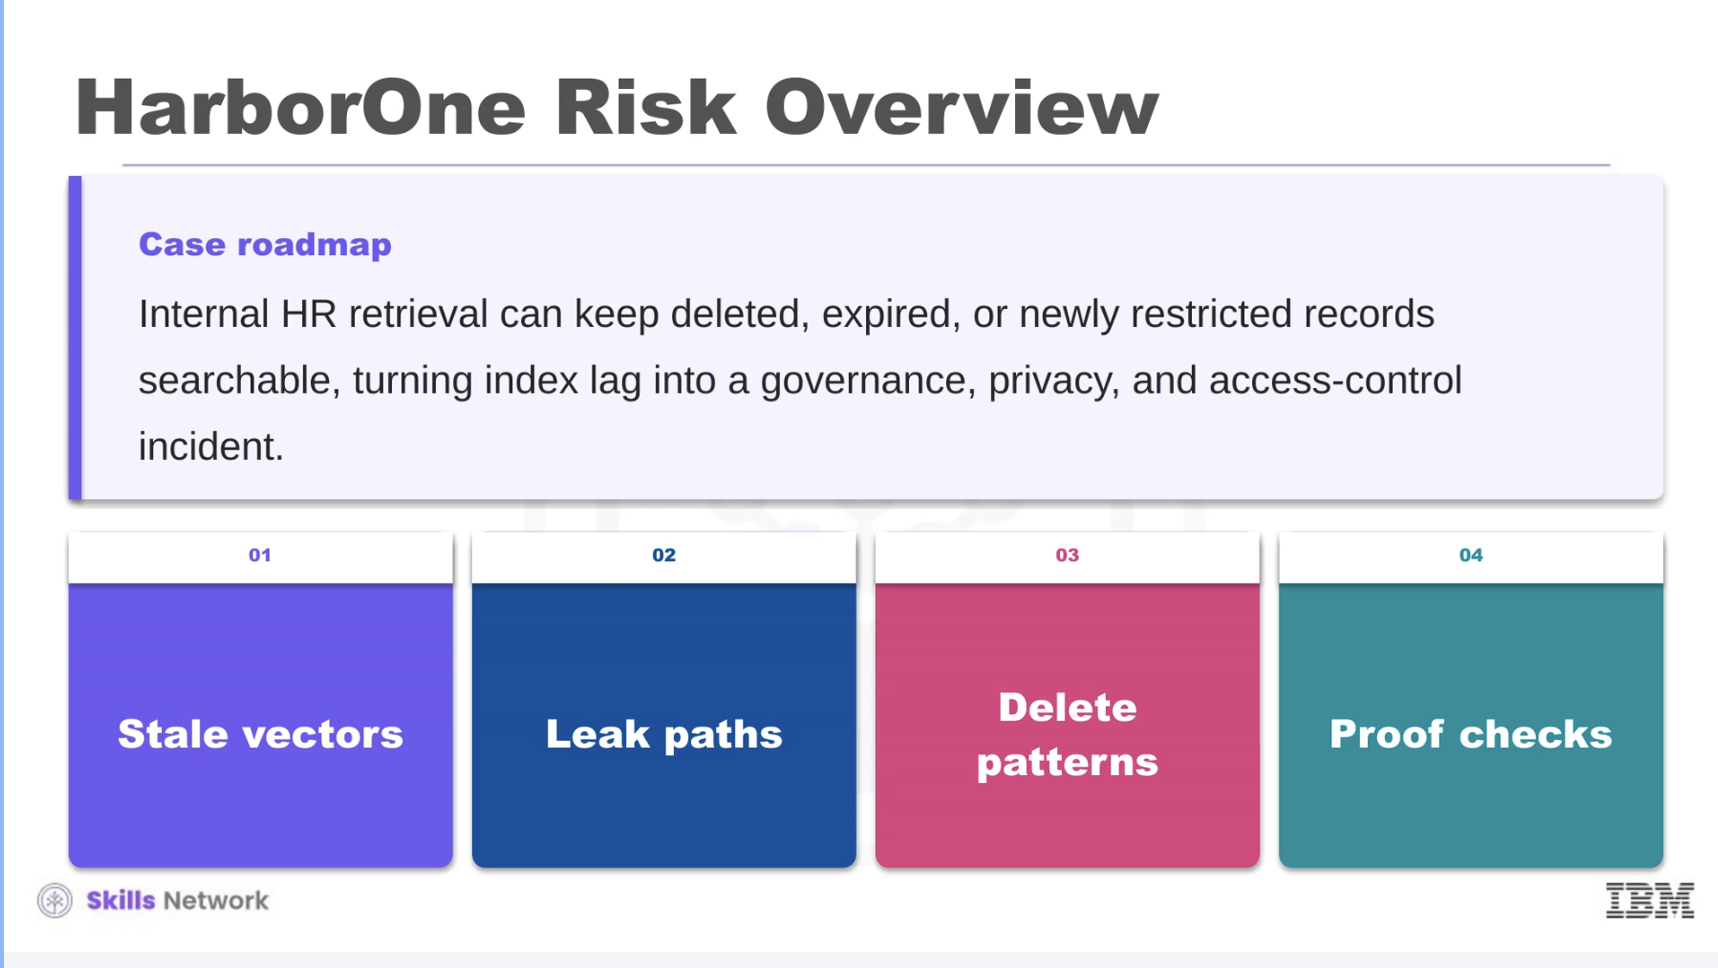
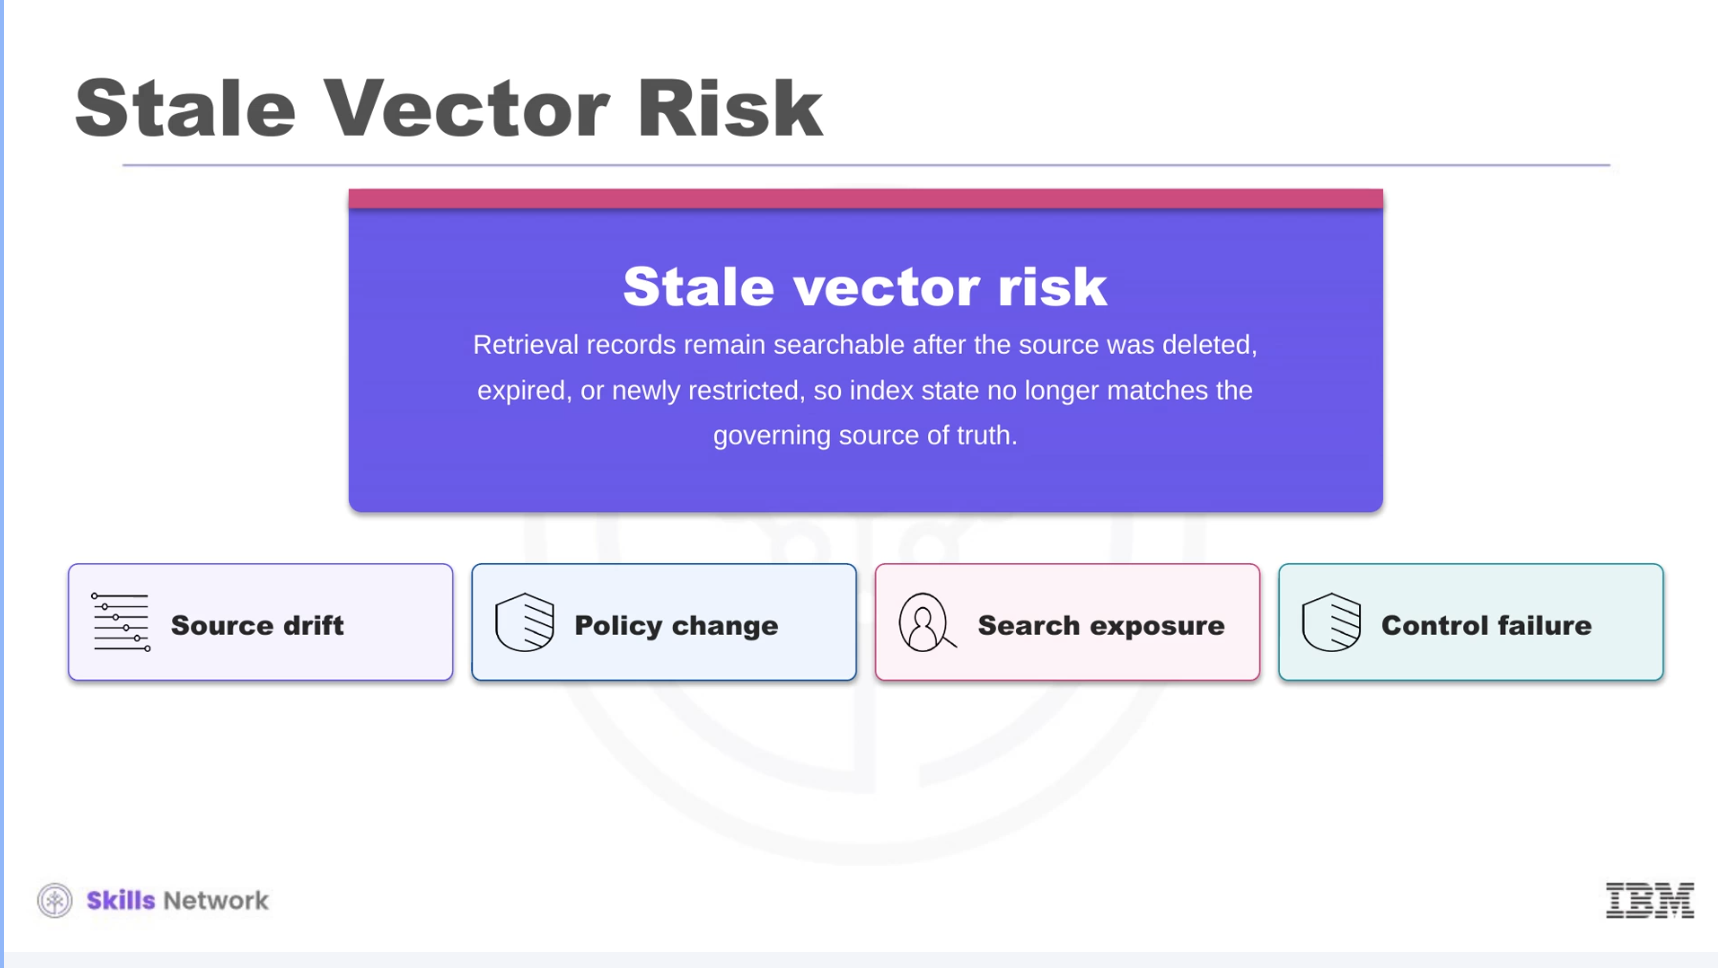
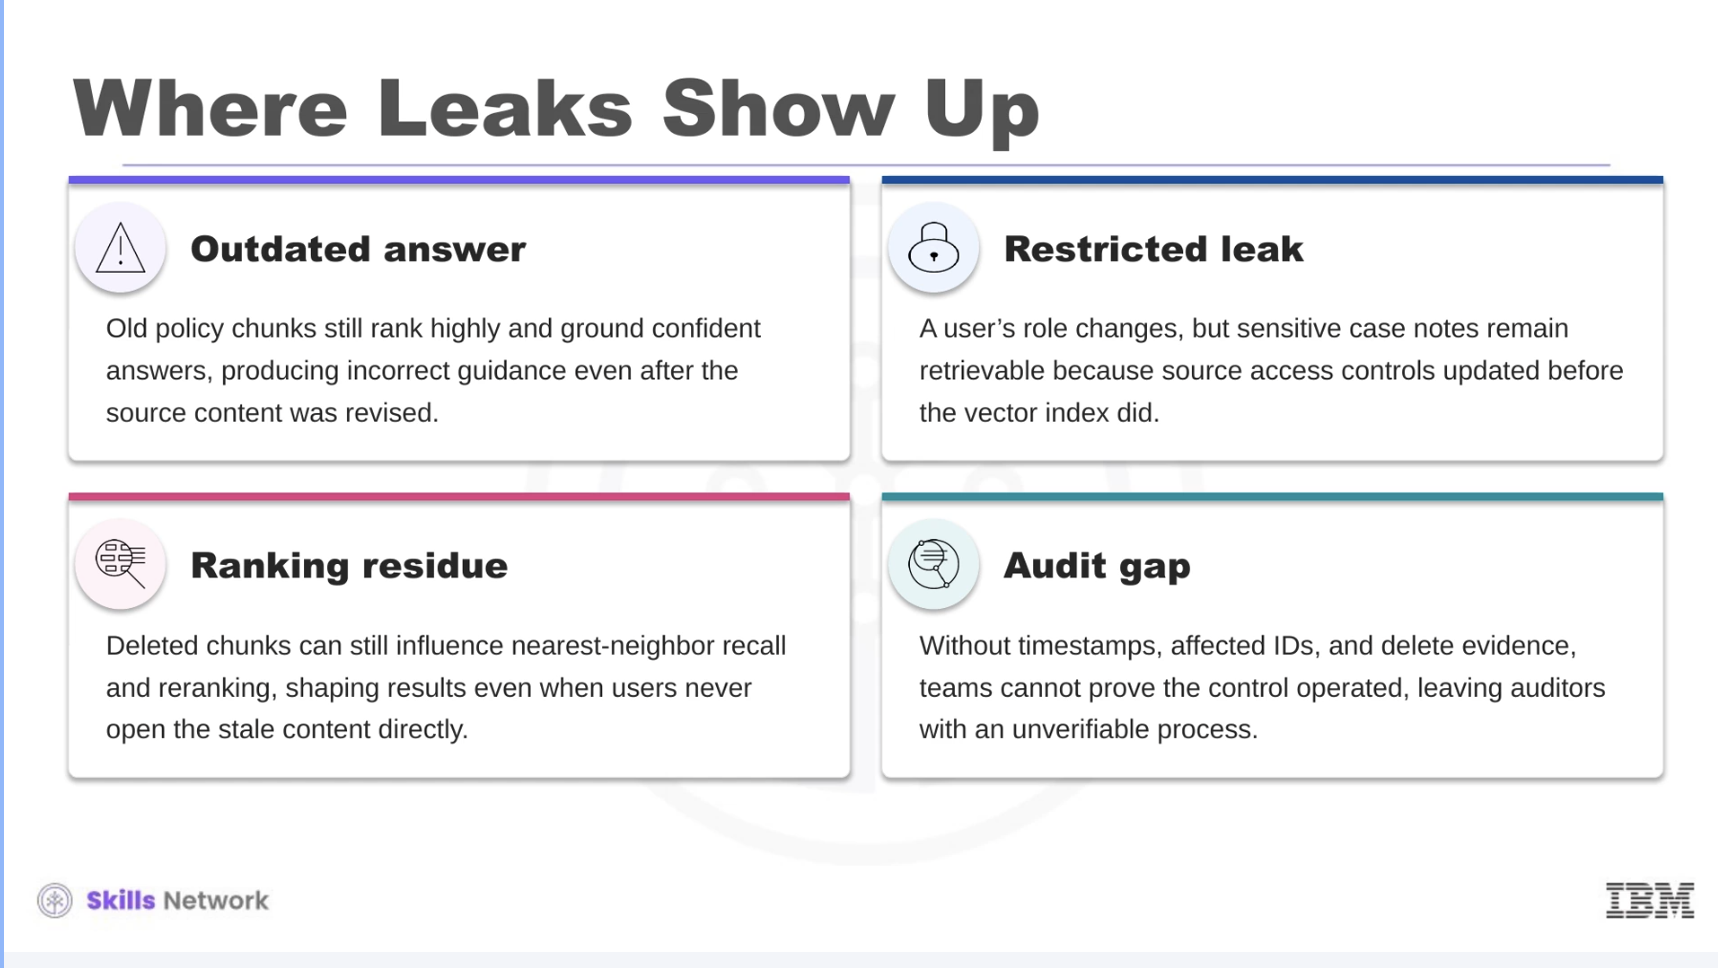
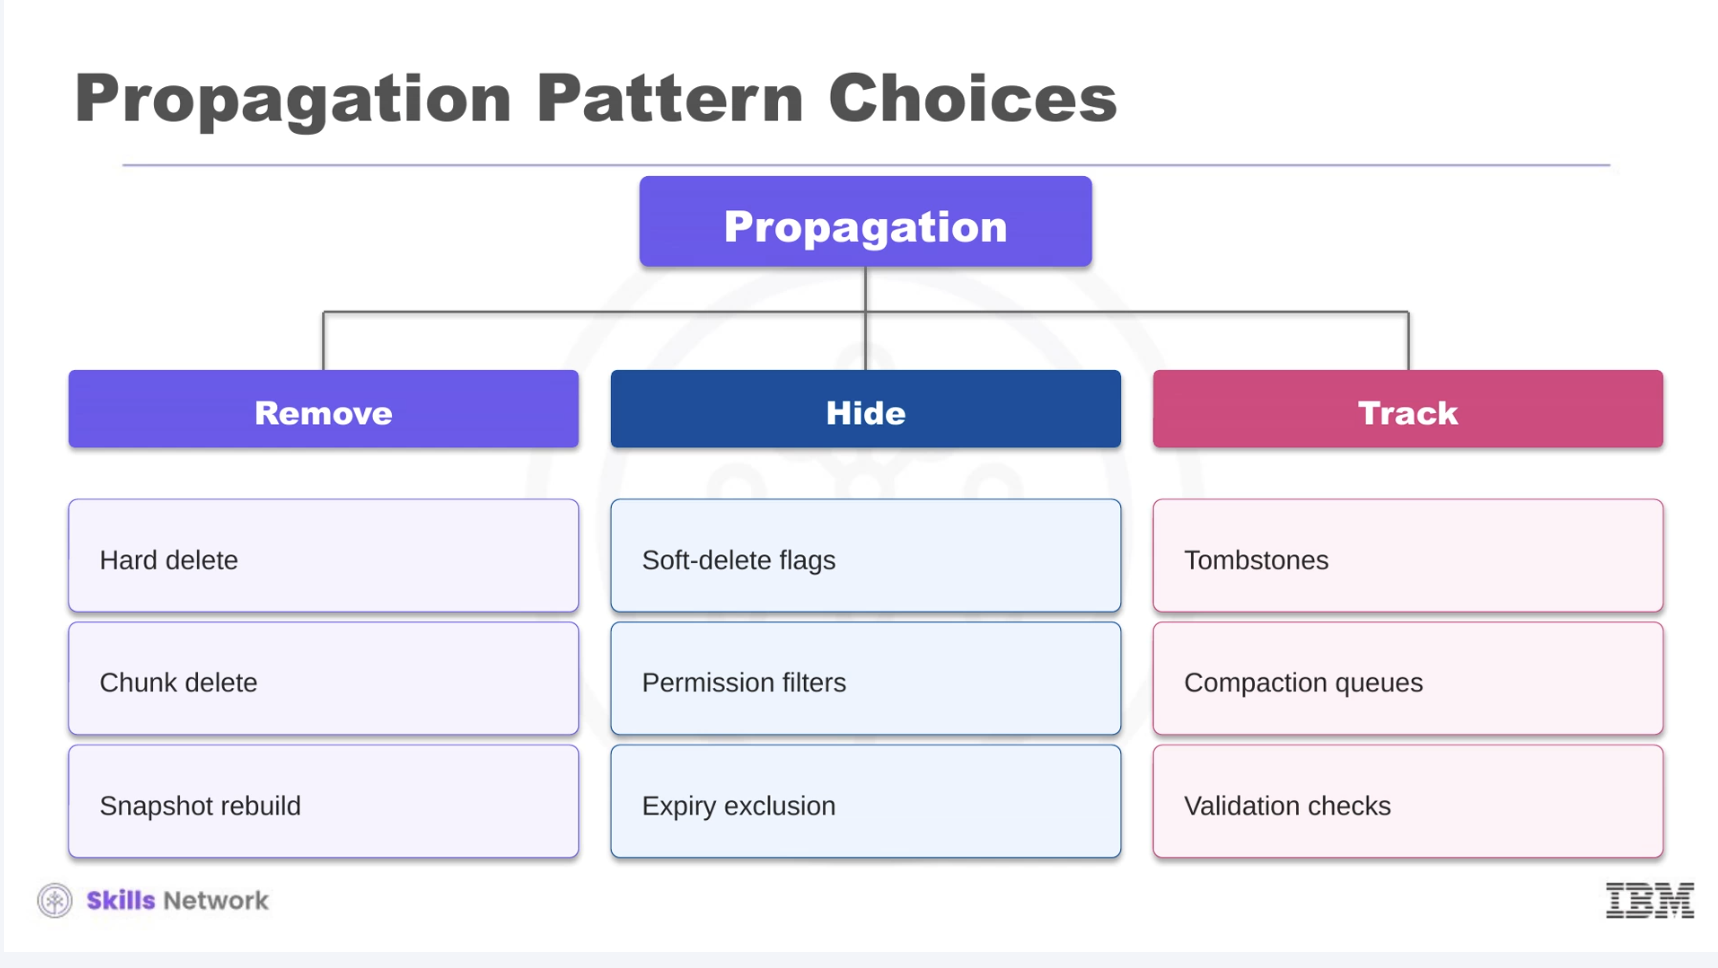
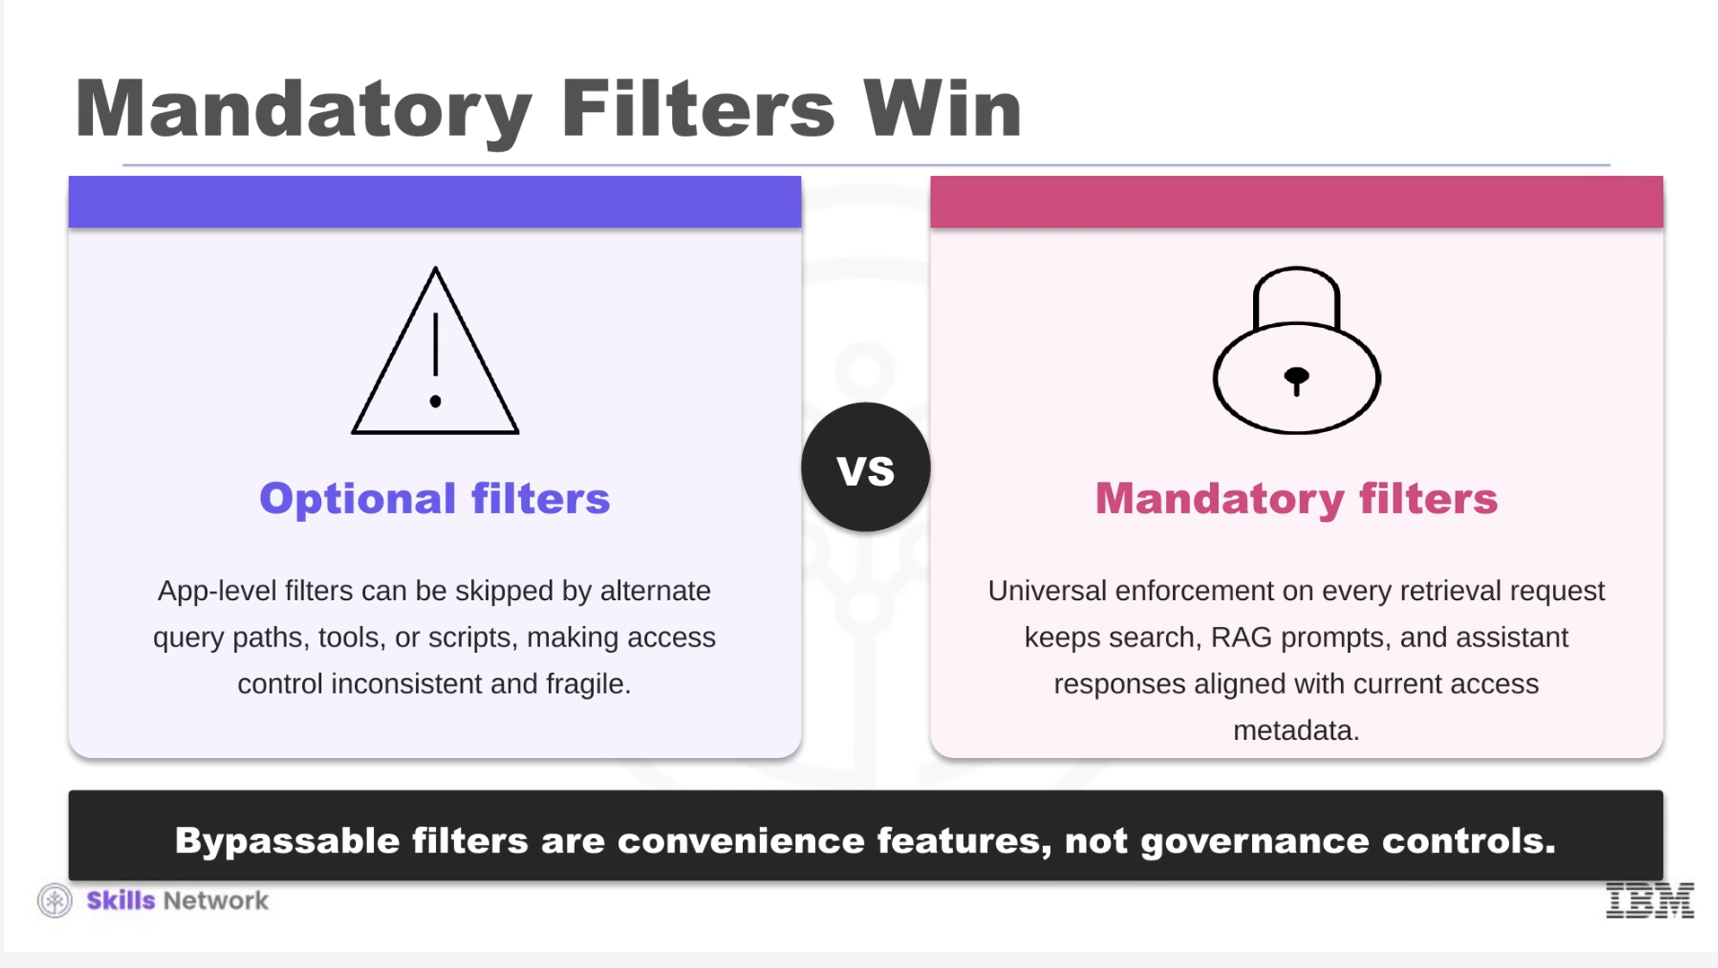
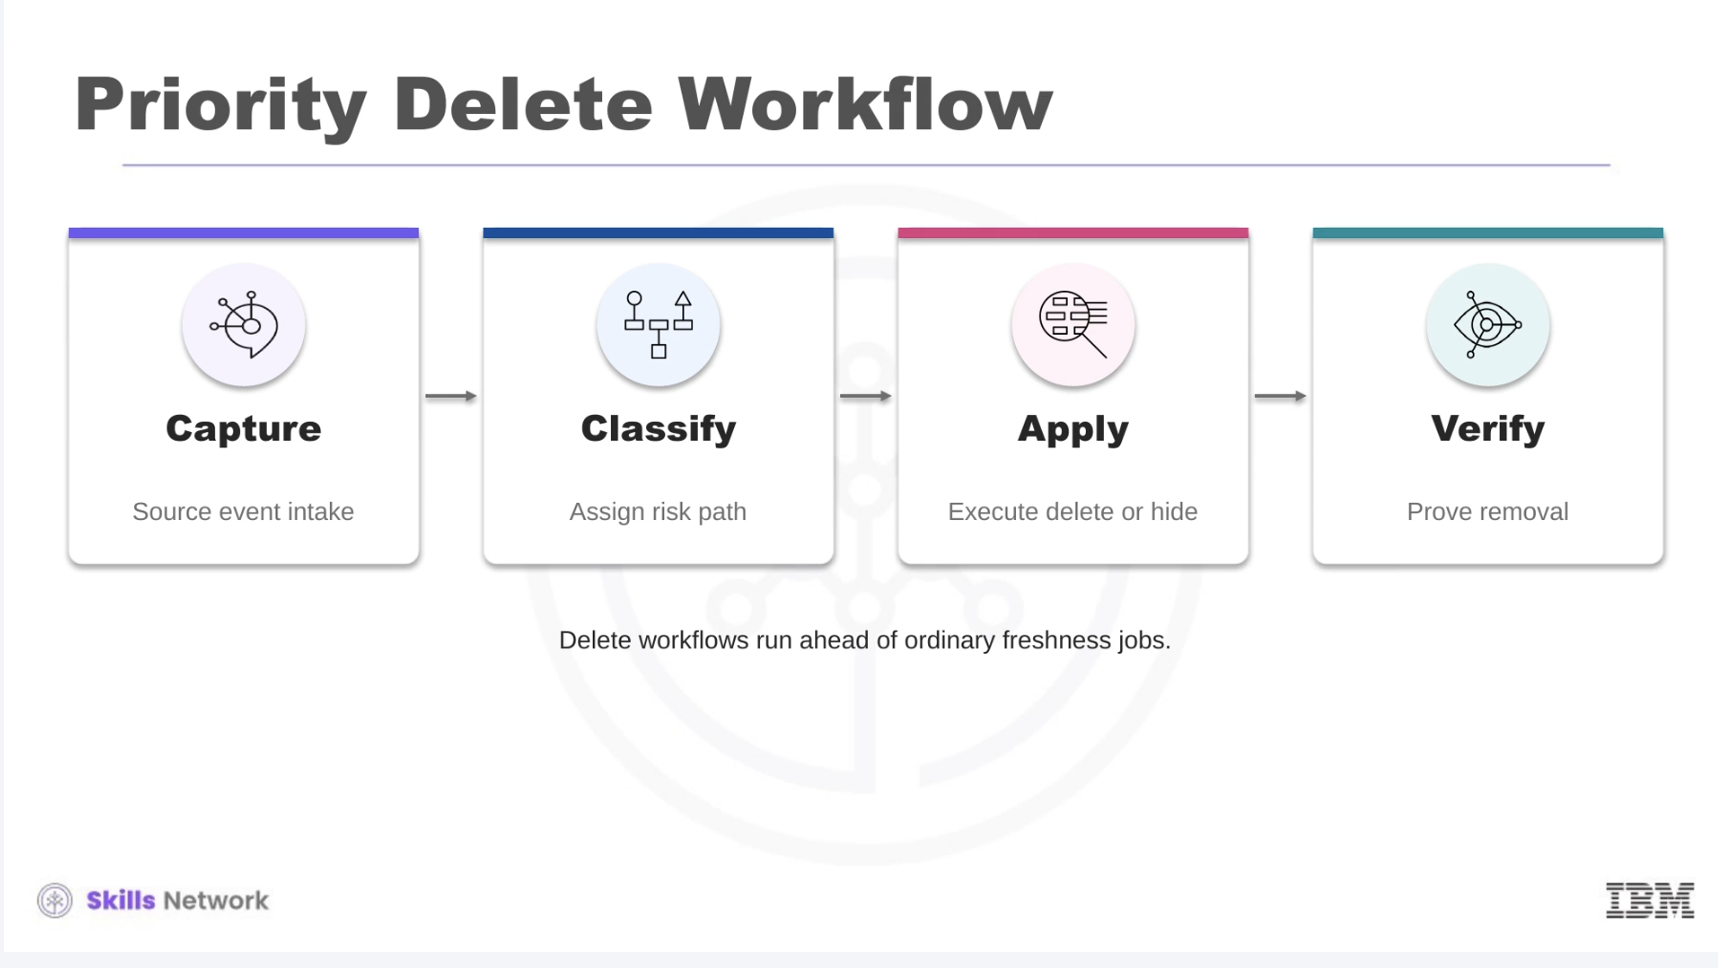
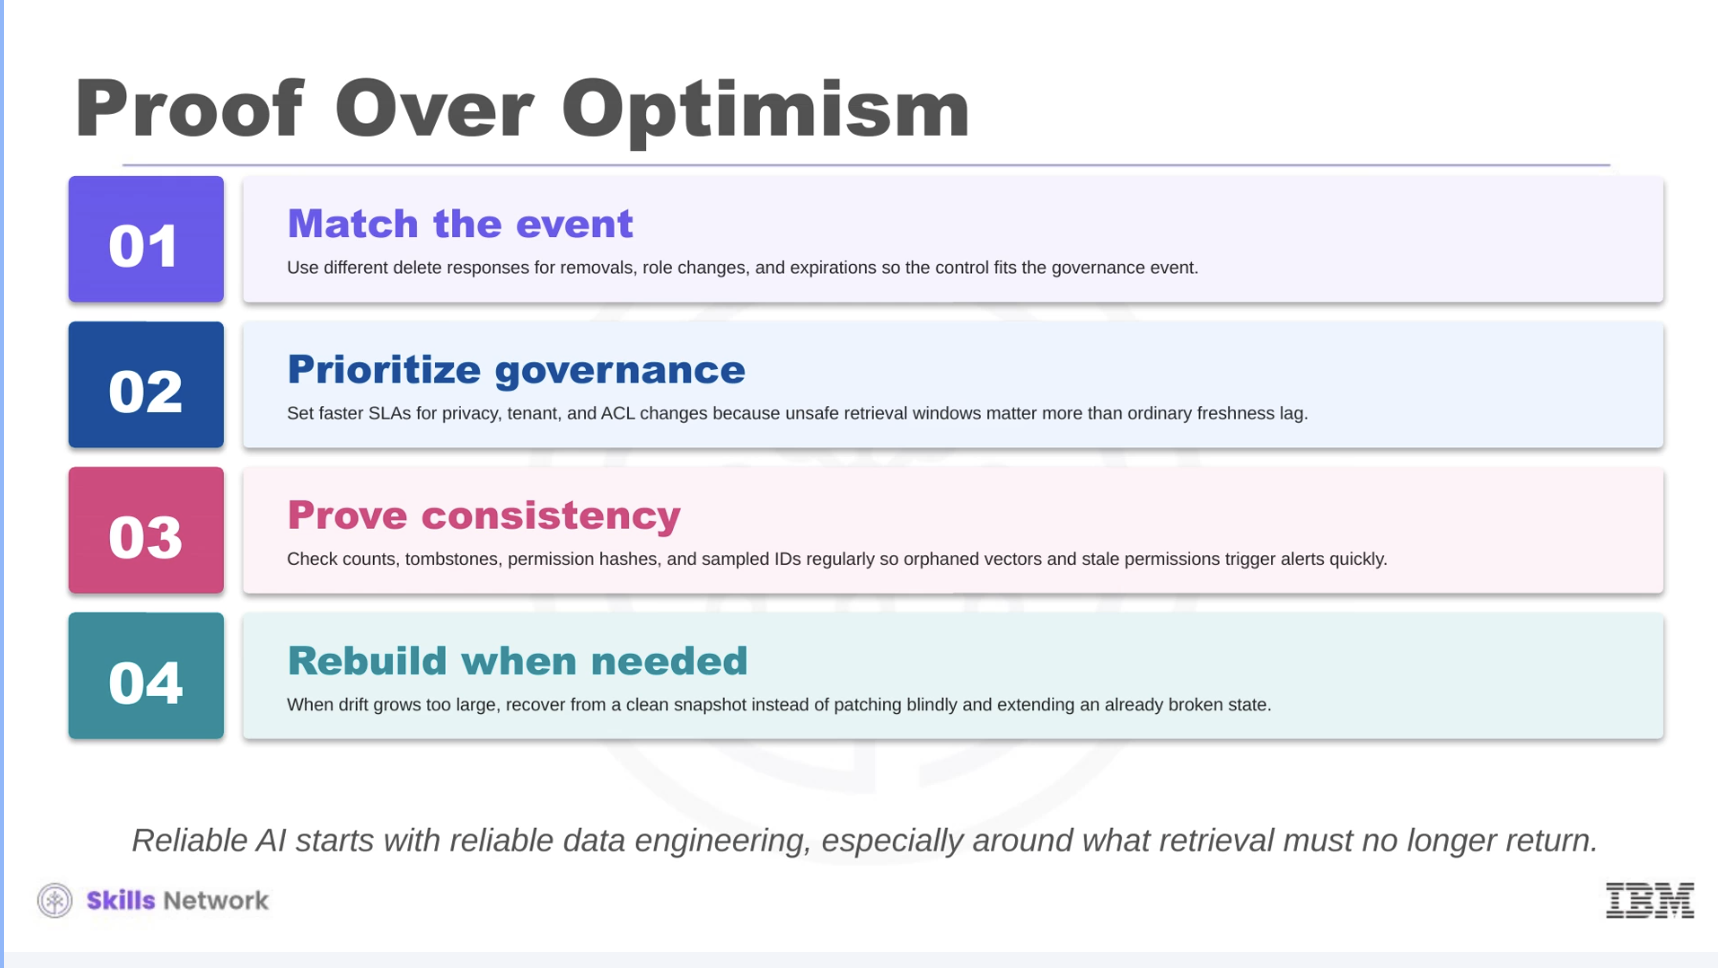


# [Design_UPDATE_DELETE_PROPOGATION_WORKFLOWS](Practical1/designUpsert.ipynb)